In [7]:
import random

from qiskit import QuantumCircuit
from qiskit.circuit.library import RYGate, XGate, ZGate, HGate, IGate, CXGate, CZGate, SwapGate
from qiskit.quantum_info import Statevector

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from tqdm import trange

In [31]:
class RandomCircuit:
    def __init__(self, seed:int=37):
        self._all_gates = {
            'x': lambda  x: XGate(), 
            'z': lambda x: ZGate(), 
            'h': lambda x: HGate(), 
            'id': lambda x: IGate(),  
            'cx': lambda x: CXGate(), 
            'cz': lambda x: CZGate(), 
            'swap': lambda x: SwapGate(), 
            'ry':lambda theta: RYGate(theta)
        }
        self._two_qubit = ['cx', 'cz', 'swap']
        self._one_qubit = ['x', 'z', 'id', 'h', 'ry']

        self._low_param = 0
        self._high_param = 2*np.pi
        
        self._rng = np.random.default_rng(seed)

    def _get_angle(self) -> float:
        return self._rng.uniform(low=self._low_param,high=self._high_param,size=None)

    
    def get_random_circuit(self, max_gates:int, num_qubits:int, max_barriers:int) -> QuantumCircuit:
        qc = QuantumCircuit(num_qubits)

        # so the circuit can be empty, with 0.1% of chance
        if self._rng.random() <= 0.001:
            # it can have variants with barriers
            num_barriers = np.random.randint(0,max_barriers)
            if not num_barriers:
                return qc

            for _ in range(num_barriers):
                qc.barrier()
            return qc
            
        c = max_gates
        b = max_barriers
        while c > 0:

            # it can stop by random in the middle
            stop_now = self._rng.random() < 0.001
            if stop_now:
                break

            which_type = 2
            r = self._rng.random()
            if r <= 0.05:
                which_type = 1
            elif r <= 0.475:
                which_type = 2
            else:
                which_type = 3

            if which_type == 1:# barrier
                if b <= 0: # no more barriers in this case
                    continue

                if b == 1:
                    qc.barrier()
                    b = 0
                    continue
                
                quantity = np.random.randint(1,b)
                b -= quantity
                
                for _ in range(quantity):
                    qc.barrier()
    
            elif which_type == 2: # one qubit gate
                quantity = 1
                if c != 1:
                    quantity = np.random.randint(1,c)
                c -= quantity

                selected_gates = random.choices(self._one_qubit,k=quantity)
                selected_qubits = random.choices(range(num_qubits),k=quantity)

                for gate,qubit in zip(selected_gates, selected_qubits):
                    angle = self._get_angle()
                    qc.append(self._all_gates[gate](angle), [qubit])
                
                    
            else: # two qubit gate
                quantity = 1
                if c != 1:
                    quantity = np.random.randint(1,c)
                c -= quantity

                selected_gates = random.choices(self._two_qubit,k=quantity)
                
                controls = [np.random.randint(0,num_qubits-1) for _ in range(quantity)]
                targets = []
                for i in range(quantity):
                    #target and control must be different
                    while True:
                        selected_target  = np.random.randint(0,num_qubits-1)
                        if selected_target != controls[i]:
                            targets.append(selected_target)
                            break
                
                for gate,c,t in zip(selected_gates, controls, targets):
                    qc.append(self._all_gates[gate](None), [c,t])
            
        if self._rng.random() <= 0.01 and b > 0:
            qc.barrier()

        return qc
        

In [26]:
r = RandomCircuit()

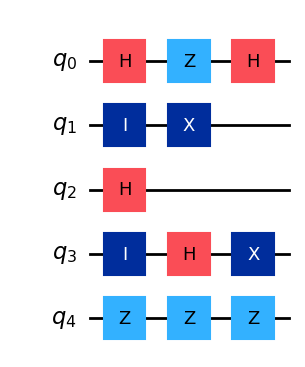

In [165]:
r.get_random_circuit(20,5,4).draw("mpl")

In [167]:
# we are testing if the algorithm can generate sparse circuits
while True:
    qc = r.get_random_circuit(20,5,4)
    vec = Statevector(qc)

    if vec[0] != 0 and vec[1] == 0 and vec[2] != 0:
        display(vec.draw("latex"))
        break

<IPython.core.display.Latex object>

In [37]:
amount = 30_000
df = pd.DataFrame(columns=["bit_string", "vec"])

for i in trange(amount):
    qc = r.get_random_circuit(20,5,4)
    vec = Statevector(qc).data.tolist()

    bit_string = ""
    for c in vec:
        if c != 0:
            bit_string += "1"
        else:
            bit_string += "0"
    df.loc[i] = {
        "bit_string": bit_string,
        "vec": vec
    }

100%|████████████████████████████████████████████████████████████████████████████| 30000/30000 [01:26<00:00, 345.32it/s]


In [38]:
len(df.bit_string.unique())

731

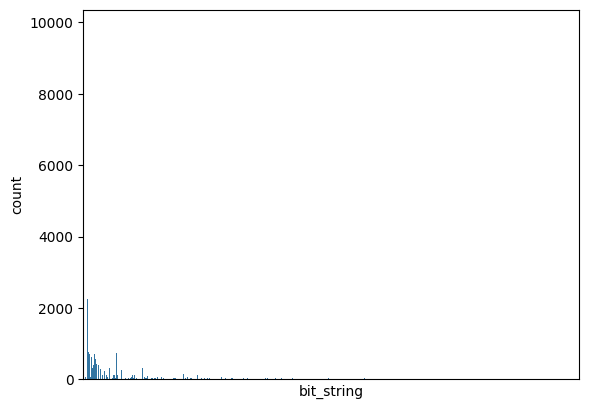

In [39]:
ax = sns.countplot(data=df, x="bit_string")
ax.set_xticks([])
plt.show()

In [43]:
counts = pd.DataFrame(df.bit_string.value_counts()).reset_index()
counts.describe()

,count
count,731.000000
mean,41.039672
std,380.948355
min,1.000000
25%,2.000000
50%,5.000000
75%,15.000000
max,9861.000000
